In [ ]:
# import tensforflow

import tensorflow as tf
tf.__version__

'2.20.0'

In [ ]:
from tensorflow.keras.datasets.mnist import load_data # for data    
from tensorflow.keras import Sequential               # for layering
from tensorflow.keras.layers import Dense             # for dense layering

In [30]:
(X_train, y_train), (X_test, y_test) = load_data()

Text(0.5, 1.0, 'Class: 0')

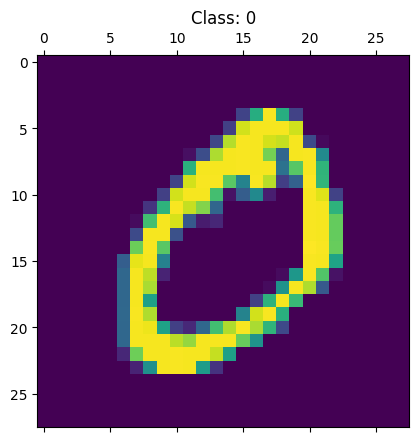

In [ ]:
# visualization
import matplotlib.pyplot as plt
plt.matshow(X_train[1])
plt.title(f"Class: {y_train[1]}")

In [ ]:

import numpy as np
np.max(X_train), np.min(X_train)

(np.float64(1.0), np.float64(0.0))

In [31]:
# normalize

X_train_norm = X_train / 255.0
X_test_norm = X_test / 255.0

Text(0.5, 1.0, 'Class: 0')

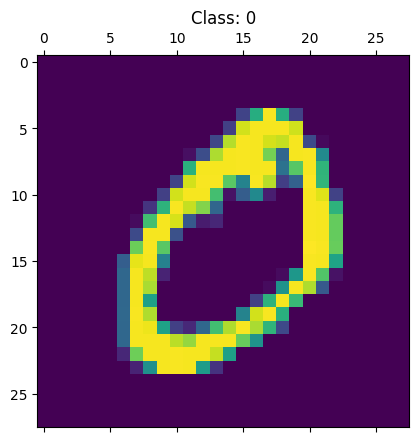

In [ ]:
# image still the same

plt.matshow(X_train[1])
plt.title(f"Class: {y_train[1]}")

In [32]:
# flatten images into 1d array

X_train_flat = X_train.reshape(60000, 784)
X_test_flat = X_test.reshape(10000, 784)

In [33]:
# one hot encoding
y_train_enc = tf.keras.utils.to_categorical(y_train)
y_test_enc = tf.keras.utils.to_categorical(y_test)

In [37]:
# model
model = Sequential()
model.add(Dense(256, activation="relu",input_shape=[784,],name="h1"))
model.add(Dense(128, activation="relu",name="h2"))
model.add(Dense(10, activation="softmax"))
model.summary()

d:\Semester\6\DL\Lib\.venv\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ h1 (Dense)                      │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ h2 (Dense)                      │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 235,146 (918.54 KB)

 Trainable params: 235,146 (918.54 KB)

 Non-trainable params: 0 (0.00 B)

In [38]:
model.compile(
    optimizer="rmsprop",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [39]:
history = model.fit(
    x=X_train_flat, y=y_train_enc,
    epochs=25,
    batch_size=32,
    validation_data=(X_test_flat,y_test_enc)
)

Epoch 1/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8677 - loss: 1.6448 - val_accuracy: 0.9113 - val_loss: 0.3985
Epoch 2/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9170 - loss: 0.4601 - val_accuracy: 0.8972 - val_loss: 0.5598
Epoch 3/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9284 - loss: 0.4273 - val_accuracy: 0.9147 - val_loss: 0.5622
Epoch 4/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.9330 - loss: 0.4113 - val_accuracy: 0.9214 - val_loss: 0.6804
Epoch 5/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9340 - loss: 0.4076 - val_accuracy: 0.9275 - val_loss: 0.5232
Epoch 6/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.9346 - loss: 0.3949 - val_accuracy: 0.9368 - val_loss: 0.7103
Epoch 7/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 17s 4ms/step - accuracy: 0.9343 - loss: 0.4192 - val_accuracy: 0.9283 - val_loss: 0.7785
Epoch 8/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9412 - loss: 0.418

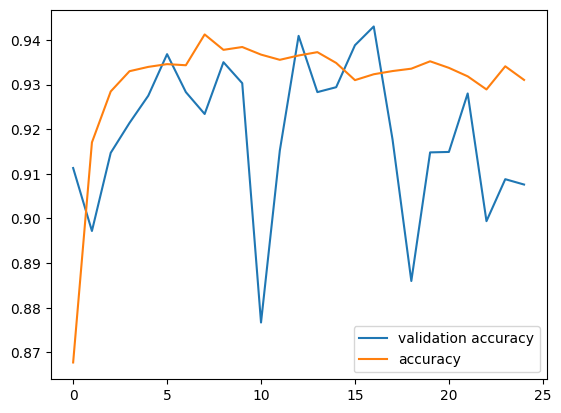

In [41]:
h = history.history
plt.plot(h["val_accuracy"], label="validation accuracy")
plt.plot(h["accuracy"], label="accuracy")
plt.legend()
plt.show()

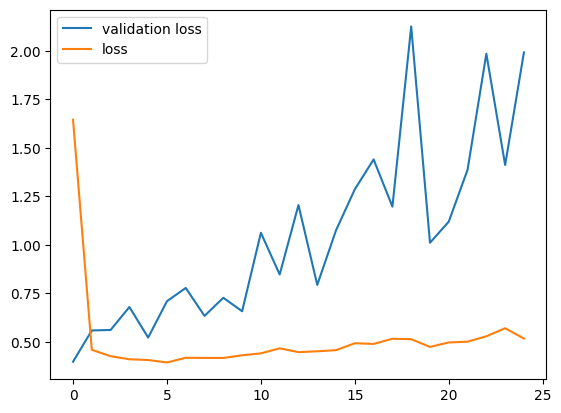

In [43]:
plt.plot(h["val_loss"],label="validation loss")
plt.plot(h["loss"], label="loss")
plt.legend()
plt.show()
